First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target

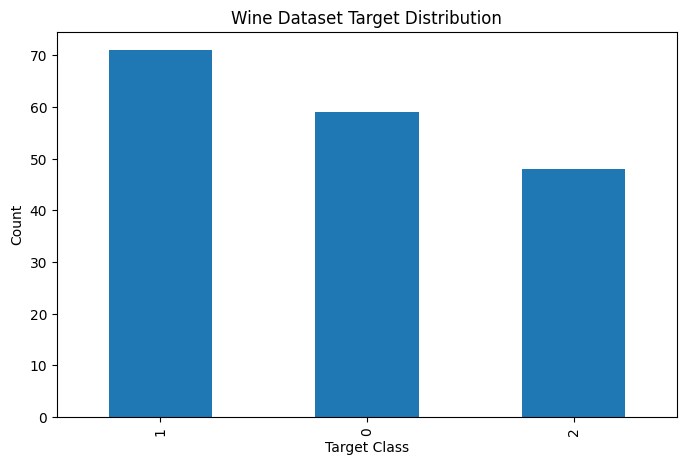

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

# Load dataset
data = load_wine(as_frame=True)
df = data.frame

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values before preprocessing:")
print(df.isnull().sum())

# Add artificial missing values for preprocessing demonstration
df.iloc[0:10, 0] = np.nan
df.iloc[20:25, 3] = np.nan

print("\nMissing values after adding sample null values:")
print(df.isnull().sum())

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create preprocessing pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Fit and transform
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("\nProcessed training data shape:")
print(X_train_processed.shape)

print("\nProcessed testing data shape:")
print(X_test_processed.shape)

# Save processed data
processed_train = pd.DataFrame(X_train_processed)
processed_test = pd.DataFrame(X_test_processed)

processed_train.to_csv("processed_train_data.csv", index=False)
processed_test.to_csv("processed_test_data.csv", index=False)

# Save pipeline
joblib.dump(pipeline, "data_pipeline.pkl")

print("\nTask 1 completed successfully!")
print("Files created:")
print("- processed_train_data.csv")
print("- processed_test_data.csv")
print("- data_pipeline.pkl")
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["target"].value_counts().plot(kind="bar")
plt.title("Wine Dataset Target Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

In [4]:
import os
print(os.getcwd())

C:\Users\91939
